# Functional Detection

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import numpy as np
import suite2p
import mbo_utilities as mbo
import lbm_suite2p_python as lsp

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA RTX A4000,DiscreteGPU,Vulkan,560.94
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
❗ limited,Microsoft Basic Render Driver,CPU,D3D12,
❌,NVIDIA RTX A4000/PCIe/SSE2,Unknown,OpenGL,4.6.0 NVIDIA 560.94


In [2]:
raw_files = mbo.get_files(r"D:\W2_DATA\wsnyder\2025_03_06\raw\dot_lv6", "tif")
scan = mbo.read_scan(raw_files)

In [18]:
mbo.save_as(scan, "D://demo_anatomical//assembled", target_chunk_mb=100)

Reading tiff series data...
Reading tiff pages...
Raw tiff fully read.


Saving planes:   0%|          | 0/56 [00:00<?, ?it/s]

Time elapsed: 0 minutes 17 seconds.


In [10]:
assembled_files = mbo.get_files("D://demo_anatomical//assembled", 'tif')
assembled_files

['D:\\demo_anatomical\\assembled\\plane_01.tif',
 'D:\\demo_anatomical\\assembled\\plane_02.tif',
 'D:\\demo_anatomical\\assembled\\plane_03.tif',
 'D:\\demo_anatomical\\assembled\\plane_04.tif',
 'D:\\demo_anatomical\\assembled\\plane_05.tif',
 'D:\\demo_anatomical\\assembled\\plane_06.tif',
 'D:\\demo_anatomical\\assembled\\plane_07.tif',
 'D:\\demo_anatomical\\assembled\\plane_08.tif',
 'D:\\demo_anatomical\\assembled\\plane_09.tif',
 'D:\\demo_anatomical\\assembled\\plane_10.tif',
 'D:\\demo_anatomical\\assembled\\plane_11.tif',
 'D:\\demo_anatomical\\assembled\\plane_12.tif',
 'D:\\demo_anatomical\\assembled\\plane_13.tif',
 'D:\\demo_anatomical\\assembled\\plane_14.tif']

In [ ]:
iw = mbo.run_gui(assembled_files[7])
iw.show()

In [22]:
iw.close()

In [11]:
demo_file = assembled_files[6]
metadata = mbo.get_metadata(demo_file)
base_ops = mbo.params_from_metadata(metadata, base_ops=suite2p.default_ops())
demo_file,  base_ops["anatomical_only"], base_ops["tau"], base_ops["threshold_scaling"]

Setting pipeline to suite2p


('D:\\demo_anatomical\\assembled\\plane_07.tif', 0, 1.0, 1.0)

## Default parameters except 
- max_overlap = 1.0 to throw out no cells
- tau = 0.3 for GCamP8s

In [14]:
from copy import deepcopy
ops = base_ops
ops["tau"] = 0.3
ops["max_overlap"] = 1.0

In [16]:
output_ops = lsp.run_plane(ops, demo_file, "D://demo_functional//results", save_folder=None, overwrite=False)

D:\demo_anatomical\assembled\plane_07.tif already has segmentation results. Skipping execution.
Generating missing plots for plane_07...
Plotting traces...
Plotting noise distribution...
Computing rastermap model...
2025-04-28 21:07:13,133 [INFO] normalizing data across axis=1
2025-04-28 21:07:13,143 [INFO] projecting out mean along axis=0
2025-04-28 21:07:13,146 [INFO] data normalized, 0.01sec
2025-04-28 21:07:13,146 [INFO] sorting activity: 300 valid samples by 903 timepoints
2025-04-28 21:07:13,215 [INFO] n_PCs = 128 computed, 0.08sec
2025-04-28 21:07:13,286 [INFO] 100 clusters computed, time 0.15sec
2025-04-28 21:07:22,526 [INFO] clusters sorted, time 9.39sec
2025-04-28 21:07:22,689 [INFO] clusters upsampled, time 9.56sec
2025-04-28 21:07:22,693 [INFO] rastermap complete, time 9.56sec
Neuron binning factor (default): 5
Plotting from 0 : 903
Plots generated successfully.


In [31]:
res = lsp.load_planar_results(output_ops)
[x for x in res.keys()]

['F', 'Fneu', 'spks', 'stat', 'iscell', 'cellprob', 'z_plane']

In [32]:
iscell = res["iscell"]
sum(iscell), sum(~iscell) # acc, rej

(300, 1013)

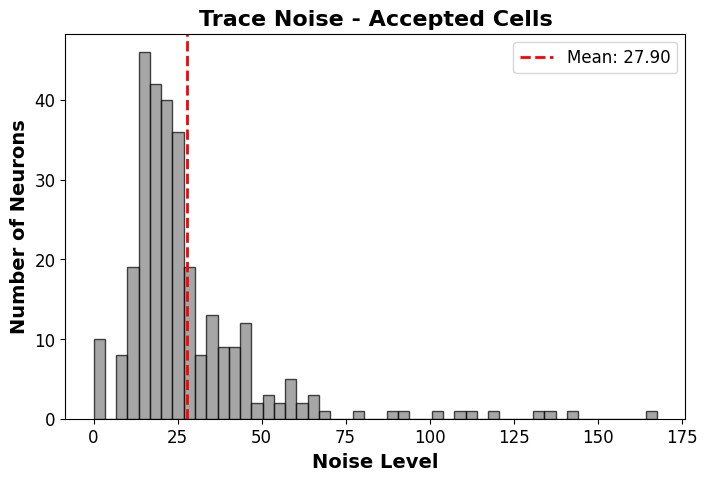

In [33]:
f = res["F"][iscell]           # raw fluo
stat = res["stat"][iscell]     # cell stats (i.e. skewness, measure of activity)
spks = res["spks"][iscell]     # deconvolved spike estimates

noise = lsp.dff_shot_noise(f, output_ops["fs"])
lsp.plot_noise_distribution(noise, title="Trace Noise - Accepted Cells")

In [34]:
model = np.load("D://demo_functional//results//plane_07//plane0//model.npy", allow_pickle=True).item()

Neuron binning factor (default): 2


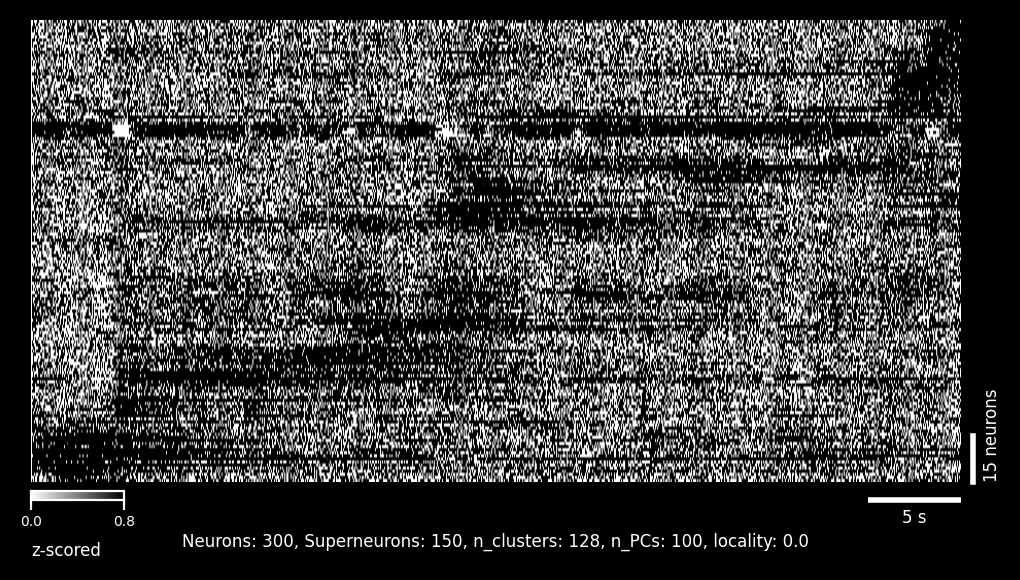

(<Figure size 1200x600 with 2 Axes>, <Axes: >)

In [39]:
lsp.plot_rastermap(
    spks=spks, model=model, neuron_bin_size=2,
)

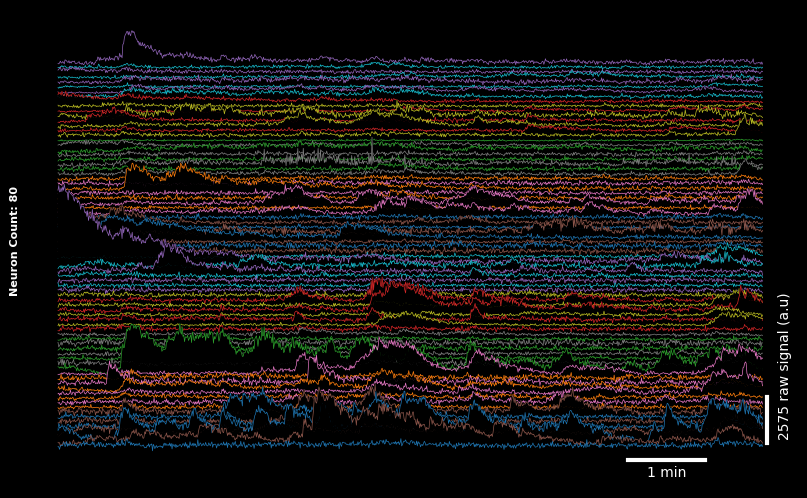

In [20]:
iscell = res["iscell"]
f = res["F"][iscell]
lsp.plot_traces(f, signal_units='raw', num_neurons=80, window=800)

In [23]:
# stat has statistics for each neuron
stat = res["stat"][iscell]
skews = np.array([x["skew"] for x in stat])
order = np.argsort(-skews)
f_skew_sort = f[order]

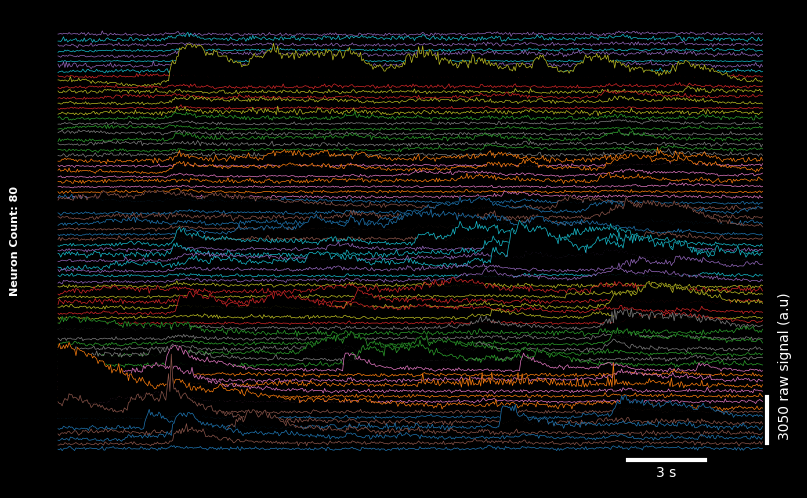

In [32]:
lsp.plot_traces(f_skew_sort, signal_units='raw', num_neurons=80, window=30)

In [34]:
ops = lsp.load_ops(r"D:/demo_functional/results/plane_07/plane0/ops.npy")
ops['anatomical_only']

3